## MNIST met Linear Regression

Bij K-means onthielden we gemiddelde plaatjes.
Nu doen we iets anders:
- We leren per cijfer een formule die zegt hoe waarschijnlijk het is dat een plaatje dat cijfer is.
- Pixels krijgen een gewicht — sommige pixels tellen zwaarder mee dan andere.

### Laden MNIST

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

def load_mnist():
    """
    Laadt MNIST, schaalt pixels naar 0-1, labels naar integers.
    """
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data / 255.0          # schalen naar 0-1
    y = mnist.target.astype(int)    # labels als integers
    return X, y

X, y = load_mnist()
print(f"X shape: {X.shape}")   # (70000, 784)
print(f"y shape: {y.shape}")

X shape: (70000, 784)
y shape: (70000,)


**Waarom schalen we pixelwaarden?**

Zodat alle features op dezelfde schaal zitten (0–1). Anders kunnen pixels met hogere waarden (0–255) onterecht meer invloed hebben op het model.

**Hoeveel features heeft één afbeelding?**

784 features (28 × 28 pixels).

### Labels geschikt maken voor regressie (One-vs-Rest)

In [2]:
def make_binary_labels(y, digit):
    """
    Zet labels om naar binair:
    - 1 als het het gekozen cijfer is
    - 0 voor alle andere cijfers
    """
    return (y == digit).astype(int)

# Voorbeeld: binaire labels voor cijfer 3
y_binary = make_binary_labels(y, 3)
print(f"Aantal 3-en: {y_binary.sum()}")
print(f"Eerste 10 labels: {y[:10]}")
print(f"Eerste 10 binair:  {y_binary[:10]}")

Aantal 3-en: 7141
Eerste 10 labels: [5 0 4 1 9 2 1 3 1 4]
Eerste 10 binair:  [0 0 0 0 0 0 0 1 0 0]


**Waarom kunnen we niet direct 0–9 voorspellen?**

Linear regression gaat er van uit dat de getallen een volgorde hebben (0 < 1 < 2 ...). Maar '9' is niet 'groter' dan '1' — het zijn categorieën, geen rangorde. Daarom trainen we 10 losse modellen (one-vs-rest).

**Wat betekent een voorspelling van 0.8?**

Het model is redelijk zeker dat dit het gekozen cijfer is. Boven de 0 = waarschijnlijk dat cijfer, hoe hoger hoe zekerder.

### Lineair model trainen

In [3]:
from sklearn.linear_model import LinearRegression

def train_linear_model(X_train, y_binary):
    model = LinearRegression()
    model.fit(X_train, y_binary)
    print(f"coef shape: {model.coef_.shape}")
    return model

**Wat is X_train hier?**  
De matrix met alle trainingsafbeeldingen: elke rij is één plaatje (784 pixelwaarden).

**En y_binary?**  
De binaire labels: 1 als het het gekozen cijfer is, anders 0.

**Wat stelt één gewicht voor?**  
Hoe belangrijk die pixel is voor het herkennen van het cijfer. Hoge waarde = die pixel is kenmerkend.

**Hoeveel gewichten heeft het model?**  
784 — één per pixel.

**Wat is model.intercept_?**  
Een verschuiving (bias). Het is de basiswaarde voordat de pixels meetellen.

### Model trainen voor 1 cijfer

In [4]:
def single_experiment(digit, loaded_mnist):
    X, y = loaded_mnist
    print(f"Model trainen voor getal {digit}")
    y_binary = make_binary_labels(y, digit)
    model = train_linear_model(X, y_binary)
    return model

# Train op cijfer 5
digit = 5
model = single_experiment(digit, (X, y))

Model trainen voor getal 5
coef shape: (784,)


### Een cijfer voorspellen

In [5]:
def predict_num(model, image, digit):
    """
    - model: getraind model voor een bepaald cijfer
    - image: de afbeelding (784 pixels)
    - digit: het echte label, zodat we kunnen vergelijken
    """
    score = model.predict([image])[0]  # [0] omdat predict een array teruggeeft, we willen 1 getal
    print(f"Score: {score:.3f}")
    if score > 0:
        print(f"Model denkt: dit IS een {digit}")
    else:
        print(f"Model denkt: dit is GEEN {digit}")
    return score

**Waarom hebben we model, image én digit nodig?**
- `model`: om de voorspelling te doen
- `image`: de pixelwaarden als input
- `digit`: om te kunnen zeggen of de voorspelling klopt (vergelijking)

**Waarom `[0]`?**

`model.predict()` verwacht meerdere afbeeldingen en geeft altijd een array terug. Met `[0]` pakken we de eerste (en enige) voorspelling eruit.

### Experimenteren op een echt getal (cijfer 5)

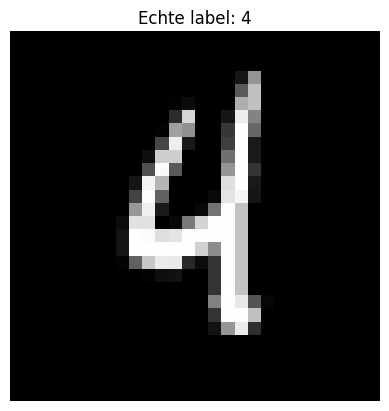

Echt label: 4
Score: 0.040
Model denkt: dit IS een 9


np.float64(0.040282474024409265)

In [64]:
import matplotlib.pyplot as plt

# Pak een willekeurig plaatje uit de dataset
random_idx = np.random.randint(0, len(X))
random_image = X[random_idx]
true_label = y[random_idx]

# Toon het plaatje
plt.imshow(random_image.reshape(28, 28), cmap="gray")
plt.title(f"Echte label: {true_label}")
plt.axis("off")
plt.show()

# Voorspel met ons model (getraind op 5)
print(f"Echt label: {true_label}")
predict_num(model, random_image, digit)

### Modellen trainen voor alle cijfers

In [7]:
def train_all_models(loaded_mnist):
    """
    Traint 10 modellen: één per cijfer (0-9).
    Geeft een dictionary terug: {0: model0, 1: model1, ...}
    """
    X, y = loaded_mnist
    models = {}
    for digit in range(10):
        y_binary = make_binary_labels(y, digit)
        models[digit] = train_linear_model(X, y_binary)
        print(f"Model {digit} getraind")
    return models

models = train_all_models((X, y))

coef shape: (784,)
Model 0 getraind
coef shape: (784,)
Model 1 getraind
coef shape: (784,)
Model 2 getraind
coef shape: (784,)
Model 3 getraind
coef shape: (784,)
Model 4 getraind
coef shape: (784,)
Model 5 getraind
coef shape: (784,)
Model 6 getraind
coef shape: (784,)
Model 7 getraind
coef shape: (784,)
Model 8 getraind
coef shape: (784,)
Model 9 getraind


### Voorspellen met alle modellen

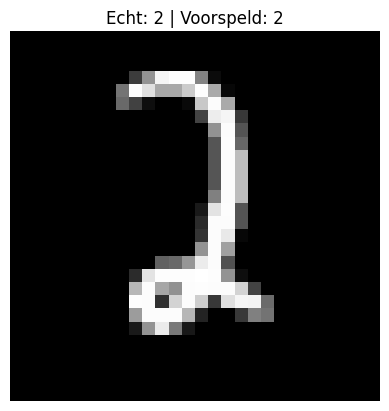

Scores per cijfer:
  0: -0.018
  1: 0.034
  2: 0.548
  3: -0.010
  4: 0.035
  5: -0.035
  6: 0.161
  7: 0.217
  8: 0.101
  9: -0.032


In [61]:
def predict_case(models, image):
    """
    Laat elk model een score geven en kies de hoogste score.
    Geeft het voorspelde cijfer terug.
    """
    scores = {digit: models[digit].predict([image])[0] for digit in range(10)}
    predicted = max(scores, key=scores.get)  # cijfer met hoogste score
    return predicted, scores

# Test op een willekeurig plaatje
random_idx = np.random.randint(0, len(X))
random_image = X[random_idx]
true_label = y[random_idx]

predicted, scores = predict_case(models, random_image)

plt.imshow(random_image.reshape(28, 28), cmap="gray")
plt.title(f"Echt: {true_label} | Voorspeld: {predicted}")
plt.axis("off")
plt.show()

print(f"Scores per cijfer:")
for d, s in scores.items():
    print(f"  {d}: {s:.3f}")

**Wat betekent een hoge score?**  
Het model is zeker dat het plaatje dat cijfer is.

**Waarom kiezen we de hoogste score?**  
Elk model geeft aan hoe goed het plaatje bij zijn cijfer past. Het model dat het meest overtuigd is, wint.

### Eigen features gebruiken

Originele features: 784
Eigen features: 7
coef shape: (7,)
Model 0 (eigen features) getraind
coef shape: (7,)
Model 1 (eigen features) getraind
coef shape: (7,)
Model 2 (eigen features) getraind
coef shape: (7,)
Model 3 (eigen features) getraind
coef shape: (7,)
Model 4 (eigen features) getraind
coef shape: (7,)
Model 5 (eigen features) getraind
coef shape: (7,)
Model 6 (eigen features) getraind
coef shape: (7,)
Model 7 (eigen features) getraind
coef shape: (7,)
Model 8 (eigen features) getraind
coef shape: (7,)
Model 9 (eigen features) getraind


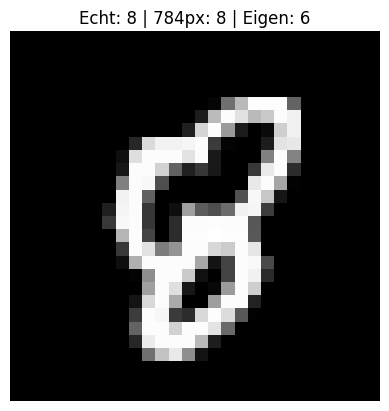

In [65]:
def extract_features(img):
    """
    Eigen features in plaats van alle 784 pixels.
    """
    features = []
    features.append(img.mean())                   # gemiddelde intensiteit
    features.append((img > 0.5).sum())             # aantal 'actieve' pixels
    features.append(img.std())                     # contrast/variatie in het plaatje
    features.append(img[:392].mean())              # gemiddelde bovenste helft
    features.append(img[392:].mean())              # gemiddelde onderste helft
    features.append(img.reshape(28,28)[:, :14].mean())   # linker helft
    features.append(img.reshape(28,28)[:, 14:].mean())   # rechter helft
    return features

# Zet alle plaatjes om naar eigen features
X_features = np.array([extract_features(img) for img in X])
print(f"Originele features: {X.shape[1]}")
print(f"Eigen features: {X_features.shape[1]}")

# Train opnieuw met eigen features
models_eigen = {}
for digit in range(10):
    y_binary = make_binary_labels(y, digit)
    models_eigen[digit] = train_linear_model(X_features, y_binary)
    print(f"Model {digit} (eigen features) getraind")

# Test vergelijking
random_idx = np.random.randint(0, len(X))
random_image = X[random_idx]
true_label = y[random_idx]

# Voorspelling met 784 pixels
pred_orig, _ = predict_case(models, random_image)

# Voorspelling met eigen features
random_features = extract_features(random_image)
pred_eigen, _ = predict_case(models_eigen, random_features)

plt.imshow(random_image.reshape(28, 28), cmap="gray")
plt.title(f"Echt: {true_label} | 784px: {pred_orig} | Eigen: {pred_eigen}")
plt.axis("off")
plt.show()

## Discussie

**Wat werkt goed?**
- Met alle 784 pixels als features presteert het model redelijk — het herkent duidelijke cijfers goed.
- One-vs-rest is een simpele maar effectieve aanpak.

**Wat werkt minder goed?**
- Linear regression is eigenlijk geen classifier — het geeft continue scores, geen echte kansen.
- De eigen features (7 getallen) bevatten veel minder informatie dan 784 pixels, dus de nauwkeurigheid daalt.

**Verschil met K-means?**
- K-means: onthield 'gemiddelde plaatjes' (unsupervised)
- Linear regression: leert gewichten per pixel op basis van labels (supervised)